[![img/pythonista.png](../img/pythonista.png)](https://www.pythonista.io)

# 🦠 COVID-19 México — Demo: Polars · Plotnine

Datos diarios de casos confirmados por estado (Feb 2020 – Jun 2023).
Fuente: CONAHCYT · CentroGeo · GeoInt · DataLab
https://datos.covid-19.conacyt.mx/#DownZCSV

## Introducción

Este notebook rehace y complementa los análisis del notebook anterior
(`01_demo_covid_mexico_pandas_seaborn.ipynb`) usando la dupla
**Polars + Plotnine**, que representa el estado del arte en análisis
tabular y visualización declarativa en Python.

### ¿Qué cambia respecto al notebook anterior?

| Aspecto | Notebook 1 (Pandas + Seaborn) | Notebook 2 (Polars + Plotnine) |
|---------|-------------------------------|--------------------------------|
| **Motor de datos** | Pandas — API imperativa, mutación en sitio | Polars — API expresiva, inmutable, paralela |
| **Evaluación** | Ansiosa (*eager*) siempre | Perezosa (*lazy*) disponible desde `scan_csv()` |
| **Formato tidy** | Se obtiene al final con `melt()` | Se construye al inicio con `unpivot()` |
| **Visualización** | Seaborn (estadística) + Matplotlib | Plotnine — Gramática de Gráficas (*Grammar of Graphics*) |
| **Análisis nuevos** | — | Curva acumulada, distribución anual por cajas |

### Herramientas utilizadas

| Librería | Rol en este notebook |
|----------|----------------------|
| **Polars** | Carga, limpieza, transformación y analítica de series temporales |
| **Plotnine** | Visualización declarativa basada en la Gramática de Gráficas |

### Estructura del notebook

| Sección | Contenido |
|---------|-----------|
| **1. Polars — carga y preparación** | `scan_csv` lazy, `unpivot()` directo a tidy, separación nacional/estatal |
| **2. Analítica con Polars** | Media móvil, día de la semana, top estados, resampleo mensual, acumulado, distribución anual |
| **3. Visualización con Plotnine** | Curva nacional, barplots, heatmap, facetas, curva acumulada, cajas anuales |

### Nota sobre calidad del dato

Aplican las mismas observaciones del notebook 1: la columna `poblacion`
corresponde al Censo 2020 (INEGI) y la sobremortalidad de la pandemia la
hace inutilizable como denominador. El ciclo artefactual semanal se mitiga
con la media móvil de 7 días.

In [1]:
import os
import polars as pl
from plotnine import (
    ggplot, aes,
    geom_line, geom_col, geom_tile, geom_boxplot, geom_area,
    facet_wrap, labs, theme, theme_bw,
    scale_fill_gradient, scale_color_brewer, scale_fill_brewer,
    scale_x_date, scale_x_discrete,
    coord_flip, element_text, element_blank,
)
import warnings

warnings.filterwarnings('ignore')

DIRECTORY = 'data'
FILE = 'Casos_Diarios_Estado_Nacional_Confirmados_20230625.csv'
PATH = os.path.join(DIRECTORY, FILE)

DIAS_SEMANA = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday',
]

print(f'Polars  {pl.__version__} ✔')

Polars  1.38.1 ✔


---
## 🐻‍❄️ PARTE 1 — Polars: carga y preparación

### 1.1 Evaluación perezosa (*lazy*) vs. ansiosa (*eager*)

Polars ofrece dos modos de ejecución:

| Función | Modo | Cuándo usar |
|---------|------|-------------|
| `pl.read_csv()` | **Eager** — lee el archivo completo de inmediato | Archivos que caben cómodamente en memoria |
| `pl.scan_csv()` | **Lazy** — construye un plan de consulta sin ejecutarlo | Archivos grandes; permite que Polars optimice antes de leer |

En modo *lazy*, Polars aplica *predicate pushdown*, *projection pushdown* y
*common subplan elimination*: técnicas que reducen el volumen de datos leído
y el tiempo de cómputo antes de llamar a `.collect()`.

`LazyFrame.collect_schema()` inspeciona el esquema inferido **sin** leer el
archivo, a diferencia del acceso directo a `.schema` que fue deprecado en
Polars 1.x por ser potencialmente costoso.

In [2]:
# scan_csv() construye el plan de ejecución sin leer el archivo a memoria.
# collect_schema() resuelve el esquema inferido de forma eficiente.
esquema = pl.scan_csv(PATH).collect_schema()

# Mostramos las primeras columnas para tener un vistazo
primeras = list(esquema.items())[:5]
for nombre, tipo in primeras:
    print(f'  {nombre}: {tipo}')
print(f'  ... ({len(esquema)} columnas en total)')

  cve_ent: Int64
  poblacion: Int64
  nombre: String
  26-02-2020: Int64
  27-02-2020: Int64
  ... (1218 columnas en total)


In [3]:
# read_csv() carga el archivo íntegro a memoria (modo eager).
# Para este dataset (~1 200 columnas × 33 filas) es la elección adecuada.
datos_crudos = pl.read_csv(PATH)
print(f'Shape: {datos_crudos.shape}  '
      f'(filas=entidades, columnas=metadatos+fechas)')
datos_crudos.head(3)

Shape: (33, 1218)  (filas=entidades, columnas=metadatos+fechas)


cve_ent,poblacion,nombre,26-02-2020,27-02-2020,28-02-2020,29-02-2020,01-03-2020,02-03-2020,03-03-2020,04-03-2020,05-03-2020,06-03-2020,07-03-2020,08-03-2020,09-03-2020,10-03-2020,11-03-2020,12-03-2020,13-03-2020,14-03-2020,15-03-2020,16-03-2020,17-03-2020,18-03-2020,19-03-2020,20-03-2020,21-03-2020,22-03-2020,23-03-2020,24-03-2020,25-03-2020,26-03-2020,27-03-2020,28-03-2020,29-03-2020,30-03-2020,…,19-05-2023,20-05-2023,21-05-2023,22-05-2023,23-05-2023,24-05-2023,25-05-2023,26-05-2023,27-05-2023,28-05-2023,29-05-2023,30-05-2023,31-05-2023,01-06-2023,02-06-2023,03-06-2023,04-06-2023,05-06-2023,06-06-2023,07-06-2023,08-06-2023,09-06-2023,10-06-2023,11-06-2023,12-06-2023,13-06-2023,14-06-2023,15-06-2023,16-06-2023,17-06-2023,18-06-2023,19-06-2023,20-06-2023,21-06-2023,22-06-2023,23-06-2023,24-06-2023
i64,i64,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
1,1434635,"""AGUASCALIENTES""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,3,1,2,1,1,4,0,17,4,6,5,3,4,…,5,1,0,14,4,7,7,6,3,2,4,10,3,3,4,1,4,8,4,2,5,1,3,1,2,3,3,2,3,0,0,4,3,2,5,0,0
2,3634868,"""BAJA CALIFORNIA""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,2,3,4,5,6,3,2,10,9,7,12,17,7,24,30,…,36,6,0,51,32,33,30,30,0,0,27,28,24,18,12,1,1,37,26,22,20,15,1,0,26,24,33,23,22,0,2,25,27,24,19,6,0
3,804708,"""BAJA CALIFORNIA SUR""",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,4,2,0,2,4,4,2,14,…,24,1,1,16,15,14,20,20,1,0,16,5,14,4,3,0,1,3,6,3,8,1,0,0,8,4,6,6,3,0,0,5,2,6,2,3,0


### 1.2 Transformación directa a formato *tidy* con `unpivot()`

En el notebook anterior con Pandas, la tabla se cargó en formato ancho y se
transformó a tidy en la sección 3.5 (justo antes de necesitarla para la
visualización). Con Polars adoptamos **tidy desde el inicio**: `unpivot()`
es la operación análoga a `DataFrame.melt()` de Pandas.

```
ANCHO (original)             TIDY (resultado)
entidad | 2020-02-26 | …    entidad  | fecha      | casos
--------|------------|--    ---------+------------+------
CDMX    |     0      | …    CDMX     | 2020-02-26 |  0
Jalisco |     0      | …    CDMX     | 2020-02-27 |  0
                            Jalisco  | 2020-02-26 |  0
```

`unpivot(index='nombre')` mantiene `nombre` como identificador y convierte
cada columna de fecha en una fila. Tras el unpivot se aplica:

- `str.to_date(format='%d-%m-%Y')` — convierte el string de fecha al tipo
  nativo `Date` de Polars.
- `cast(pl.Int32)` — convierte los conteos de `Int64` (inferido) a `Int32`,
  suficiente para valores de hasta ~2 000 millones.

In [4]:
# Pipeline completo: bruto → limpio → tidy.
# Cada método devuelve un nuevo DataFrame (Polars es inmutable).
datos_tidy = (
    datos_crudos
    .drop(['cve_ent', 'poblacion'])      # eliminar metadatos no usados
    .unpivot(                            # ancho → largo (tidy)
        index='nombre',
        variable_name='fecha',
        value_name='casos',
    )
    .rename({'nombre': 'entidad'})       # nombre más descriptivo
    .with_columns([
        pl.col('fecha').str.to_date(format='%d-%m-%Y'),
        pl.col('casos').cast(pl.Int32),
    ])
    .sort(['entidad', 'fecha'])          # orden canónico para series temporales
)

print(f'Shape tidy: {datos_tidy.shape}')
print(f'Tipos: fecha={datos_tidy["fecha"].dtype}, '
      f'casos={datos_tidy["casos"].dtype}')
datos_tidy.head(8)

Shape tidy: (40095, 3)
Tipos: fecha=Date, casos=Int32


entidad,fecha,casos
str,date,i32
"""AGUASCALIENTES""",2020-02-26,0
"""AGUASCALIENTES""",2020-02-27,0
"""AGUASCALIENTES""",2020-02-28,0
"""AGUASCALIENTES""",2020-02-29,0
"""AGUASCALIENTES""",2020-03-01,0
"""AGUASCALIENTES""",2020-03-02,0
"""AGUASCALIENTES""",2020-03-03,0
"""AGUASCALIENTES""",2020-03-04,0


In [5]:
# La fila 'Nacional' es el agregado de todos los estados.
# Se separa para evitar doble conteo en análisis estatales.
nacional_tidy = datos_tidy.filter(pl.col('entidad') == 'Nacional')
entidades_tidy = datos_tidy.filter(pl.col('entidad') != 'Nacional')

print(f'nacional_tidy:  {nacional_tidy.shape[0]:>6} registros '
      f'({nacional_tidy["fecha"].n_unique()} fechas)')
print(f'entidades_tidy: {entidades_tidy.shape[0]:>6} registros '
      f'({entidades_tidy["entidad"].n_unique()} estados)')

nacional_tidy:    1215 registros (1215 fechas)
entidades_tidy:  38880 registros (32 estados)


---
## 📊 PARTE 2 — Analítica con Polars

Polars expresa todas las transformaciones mediante **expresiones** (`pl.col(...)`)
que se evalúan de forma vectorizada y, cuando es posible, en paralelo.
No existe equivalente a los bucles `apply` de Pandas: la API obliga a pensar
en columnas completas, no fila a fila.

### 2.1 Media móvil de 7 días

`Expr.rolling_mean(window_size=7)` calcula la media de las últimas *n* filas.
Como el DataFrame ya está ordenado por fecha, esto equivale a promediar los
últimos 7 días. Las primeras 6 observaciones producen `null` porque la ventana
aún no está completa — comportamiento más honesto que rellenar con menos datos.

In [6]:
# rolling_mean opera en el orden actual del DataFrame.
# Requiere que los datos estén ordenados por fecha (garantizado en datos_tidy).
nacional_mm = (
    nacional_tidy
    .with_columns(
        pl.col('casos')
          .rolling_mean(window_size=7)
          .alias('media_movil_7d')
    )
)
# Los primeros 6 valores son null porque la ventana está incompleta.
nacional_mm.head(10)

entidad,fecha,casos,media_movil_7d
str,date,i32,f64
"""Nacional""",2020-02-26,0,null
"""Nacional""",2020-02-27,4,null
"""Nacional""",2020-02-28,2,null
"""Nacional""",2020-02-29,2,null
"""Nacional""",2020-03-01,2,null
"""Nacional""",2020-03-02,5,null
"""Nacional""",2020-03-03,9,3.428571
"""Nacional""",2020-03-04,10,4.857143
"""Nacional""",2020-03-05,11,5.857143


### 2.2 Distribución de casos por día de la semana

`dt.weekday()` devuelve un entero (0 = lunes … 6 = domingo).
`dt.to_string('%A')` devuelve el nombre en inglés. Ambas columnas se crean
en un solo `with_columns()`: Polars evalúa todas las expresiones del bloque
en paralelo.

> **Nota:** `dt.to_string('%A')` devuelve siempre nombres en inglés. Para
> español en Linux/macOS: `dt.to_string('%A', use_locale=True)` con el
> locale `es_ES` configurado en el sistema.

El resultado se agrupa por `['num_dia', 'dia']` para conservar el número
de orden y facilitar el ordenamiento posterior.

In [7]:
dist_dias = (
    nacional_tidy
    .with_columns([
        pl.col('fecha').dt.weekday().alias('num_dia'),   # 0=lunes … 6=domingo
        pl.col('fecha').dt.to_string('%A').alias('dia'),
    ])
    .group_by(['num_dia', 'dia'])
    .agg(pl.col('casos').mean().round(1).alias('promedio'))
    .sort('num_dia')          # orden lunes → domingo
)
dist_dias

num_dia,dia,promedio
i8,str,f64
1,"""Monday""",8467.4
2,"""Tuesday""",8028.6
3,"""Wednesday""",7646.8
4,"""Thursday""",7299.0
5,"""Friday""",6883.9
6,"""Saturday""",3225.0
7,"""Sunday""",2427.8


### 2.3 Top 10 estados con más casos confirmados

`group_by('entidad').agg(pl.col('casos').sum())` es el equivalente a
`DataFrame.groupby('entidad').sum()` de Pandas, pero con la diferencia de
que la expresión de agregación se declara **explícitamente**: se sabe de
antemano qué columnas se agregan y con qué función.

In [8]:
top_estados = (
    entidades_tidy
    .group_by('entidad')
    .agg(pl.col('casos').sum().alias('total'))
    .sort('total', descending=True)
    .head(10)
)
top_estados

entidad,total
str,i32
"""DISTRITO FEDERAL""",1902003
"""MEXICO""",760699
"""NUEVO LEON""",430451
"""GUANAJUATO""",373665
"""JALISCO""",299317
"""SAN LUIS POTOSI""",256705
"""VERACRUZ""",241059
"""PUEBLA""",226235
"""TABASCO""",222063


### 2.4 Agregación mensual con `group_by_dynamic()`

`group_by_dynamic()` es el equivalente temporal de `resample()` en Pandas.
Agrupa filas por ventanas de tiempo definidas con cadenas como `'1mo'`,
`'1w'`, `'1d'`, `'6h'`, etc.

| Parámetro | Significado |
|-----------|-------------|
| `index_column` | Columna de fecha que define la ventana |
| `every='1mo'` | Tamaño de cada ventana: un mes calendario |
| `group_by='entidad'` | Agrupa independientemente por cada estado |

> **Versión Pandas equivalente:** `df.resample('ME').sum()`

In [9]:
# is_in() acepta listas de Python; pasar la Serie directamente está deprecado en Polars 1.x.
top_nombres = top_estados['entidad'].to_list()

acumulados_mensuales = (
    entidades_tidy
    .filter(pl.col('entidad').is_in(top_nombres))
    .sort('fecha')
    .group_by_dynamic('fecha', every='1mo', group_by='entidad')
    .agg(pl.col('casos').sum())
    .with_columns(
        pl.col('fecha').dt.to_string('%y-%m').alias('mes_str')
    )
    .sort(['entidad', 'fecha'])
)
acumulados_mensuales.head(8)

entidad,fecha,casos,mes_str
str,date,i32,str
"""DISTRITO FEDERAL""",2020-02-01,2,"""20-02"""
"""DISTRITO FEDERAL""",2020-03-01,879,"""20-03"""
"""DISTRITO FEDERAL""",2020-04-01,8719,"""20-04"""
"""DISTRITO FEDERAL""",2020-05-01,23580,"""20-05"""
"""DISTRITO FEDERAL""",2020-06-01,24298,"""20-06"""
"""DISTRITO FEDERAL""",2020-07-01,27227,"""20-07"""
"""DISTRITO FEDERAL""",2020-08-01,26753,"""20-08"""
"""DISTRITO FEDERAL""",2020-09-01,29774,"""20-09"""


### 2.5 Casos acumulados nacionales *(análisis nuevo)*

`Expr.cum_sum()` calcula la suma acumulada fila a fila. Sobre la serie de
casos diarios nacionales produce la **curva de incidencia acumulada**:
la integral discreta de la curva epidémica.

Esta visualización complementa a la curva diaria: mientras la curva diaria
muestra la *velocidad* de la epidemia (cuántos casos nuevos por día), la
curva acumulada muestra el *volumen total* alcanzado, y sus inflexiones
(cambios de pendiente) corresponden exactamente a los picos de cada ola.

In [10]:
acumulado_nacional = (
    nacional_tidy
    .sort('fecha')
    .with_columns(
        pl.col('casos').cum_sum().alias('acumulado')
    )
    .select(['fecha', 'casos', 'acumulado'])
)

total = int(acumulado_nacional['acumulado'][-1])
print(f'Total de casos confirmados acumulados: {total:,}')
acumulado_nacional.tail(5)

Total de casos confirmados acumulados: 7,633,355


fecha,casos,acumulado
date,i32,i32
2023-06-20,444,7632334
2023-06-21,405,7632739
2023-06-22,388,7633127
2023-06-23,213,7633340
2023-06-24,15,7633355


### 2.6 Distribución anual de casos *(análisis nuevo)*

Agrupar por año permite comparar la **distribución estadística** de los
casos diarios en cada fase de la pandemia: ¿qué tan dispersos eran los
datos? ¿cuál fue la mediana? ¿hubo valores atípicos extremos?

Se excluye 2023 porque el año está incompleto (datos hasta junio), lo que
sesgaría la comparación.

In [11]:
casos_por_anio = (
    nacional_tidy
    .with_columns(
        pl.col('fecha').dt.year().cast(pl.String).alias('año')
    )
    .filter(pl.col('año').is_in(['2020', '2021', '2022']))  # años completos
)
(casos_por_anio
 .group_by('año')
 .agg([
     pl.col('casos').mean().round(0).alias('media_diaria'),
     pl.col('casos').median().alias('mediana_diaria'),
     pl.col('casos').max().alias('pico_maximo'),
 ])
 .sort('año'))

año,media_diaria,mediana_diaria,pico_maximo
str,f64,f64,i32
"""2020""",4913.0,4812.5,16224
"""2021""",6948.0,4462.0,25605
"""2022""",8819.0,2217.0,81302


---
## 🎨 PARTE 3 — Visualización con Plotnine

### La Gramática de Gráficas (*Grammar of Graphics*)

Plotnine implementa en Python la Gramática de Gráficas de Leland Wilkinson,
popularizada en R por **ggplot2** de Hadley Wickham. Toda gráfica se construye
combinando capas con el operador `+`:

```
ggplot(data, aes(x=..., y=..., color=...))   ← datos y mapeos estéticos
  + geom_*()       ← geometría (línea, barra, punto, caja, …)
  + stat_*()       ← transformación estadística opcional
  + scale_*()      ← escalas de ejes y colores
  + facet_*()      ← división en paneles
  + labs()         ← etiquetas
  + theme_*()      ← estilo visual
```

Esta arquitectura contrasta con Seaborn (funciones de alto nivel) y
Matplotlib (API imperativa de bajo nivel): en Plotnine el gráfico se
**declara**, no se construye paso a paso.

### 3.1 Curva epidémica nacional con media móvil

Dos geometrías superpuestas sobre el mismo sistema de coordenadas:

- `geom_line()` con `alpha` bajo para los casos diarios (ruido visible).
- `geom_line()` más grueso y opaco para la media móvil (tendencia).

El color se asigna manualmente con `color=` en cada `geom_*()`. Para
leyenda automática se asignaría `color=` dentro de `aes()`.

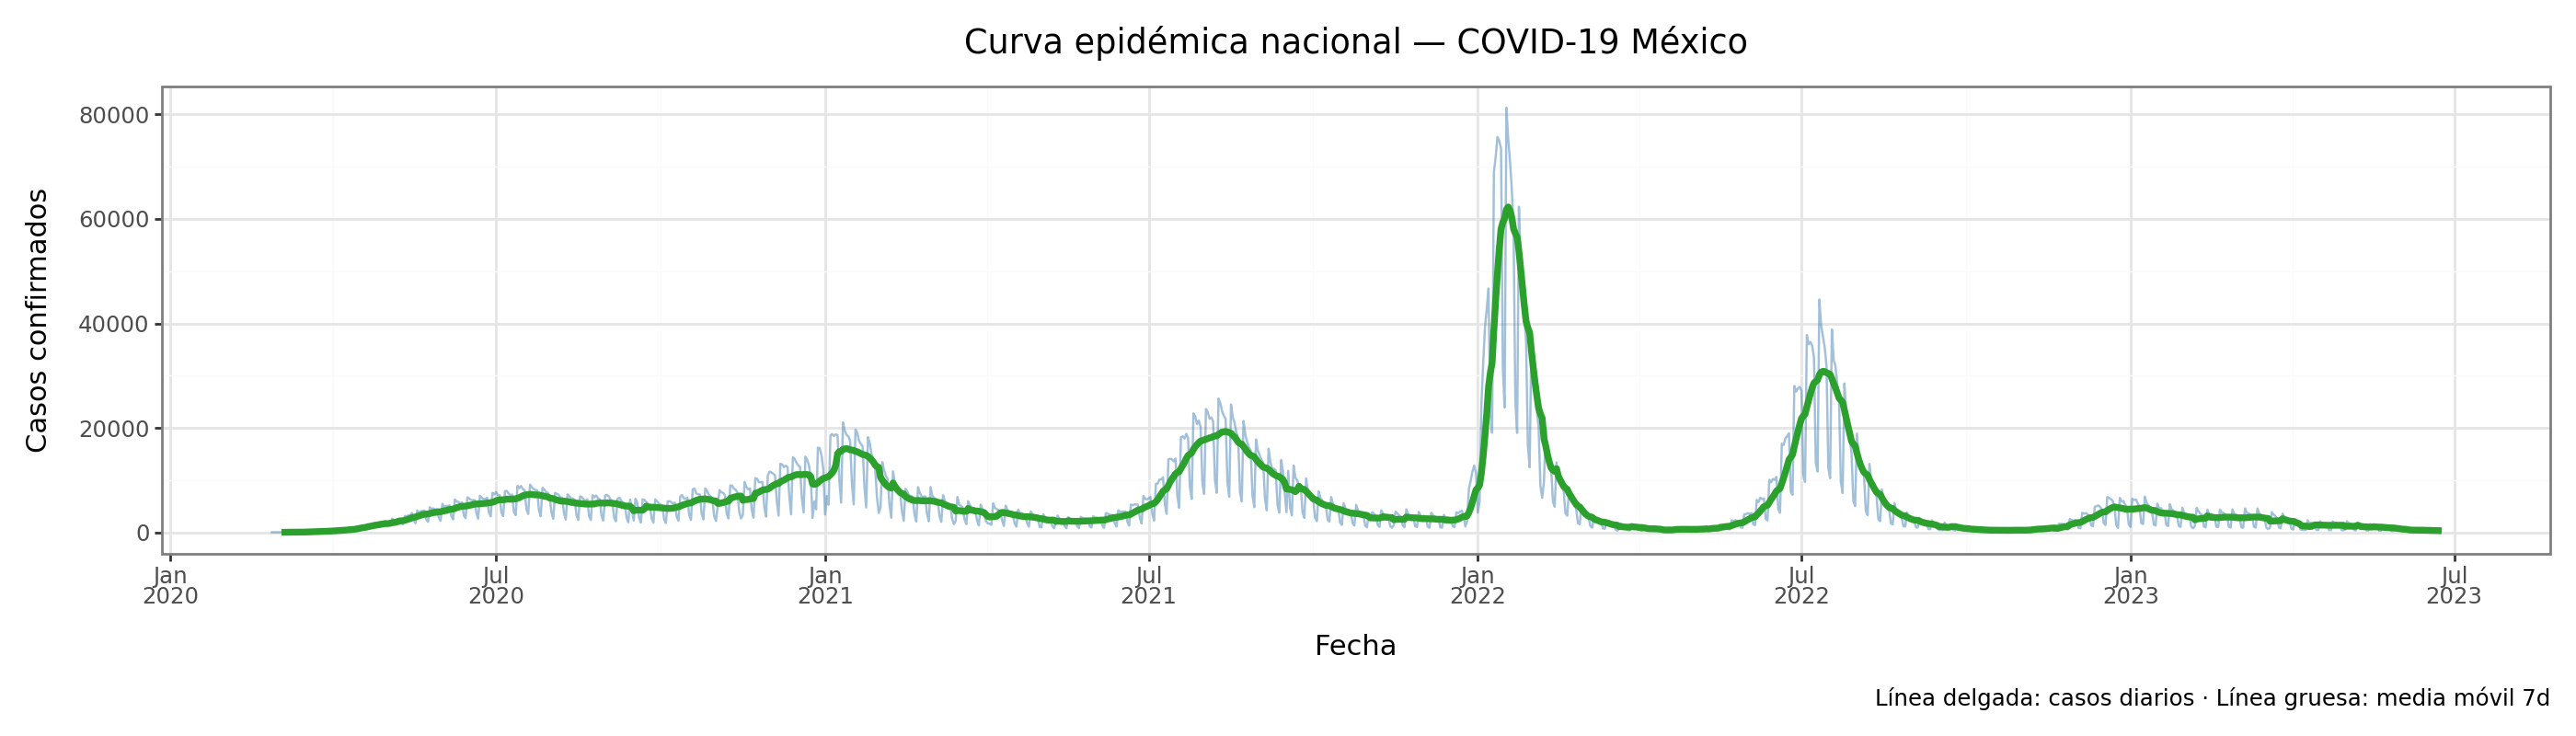

In [12]:
(ggplot(nacional_mm, aes(x='fecha'))
 + geom_line(aes(y='casos'),
             color='steelblue', size=0.5, alpha=0.5)
 + geom_line(aes(y='media_movil_7d'),
             color='#2ca02c', size=1.5)
 + scale_x_date(date_breaks='6 months', date_labels='%b\n%Y')
 + labs(title='Curva epidémica nacional — COVID-19 México',
        x='Fecha', y='Casos confirmados',
        caption='Línea delgada: casos diarios · Línea gruesa: media móvil 7d')
 + theme_bw()
 + theme(figure_size=(14, 4)))

### 3.2 Distribución de casos por día de la semana

`scale_x_discrete(limits=DIAS_SEMANA)` establece el orden del eje categórico
de lunes a domingo, equivalente a definir un factor ordenado en R.
`scale_fill_gradient()` codifica el promedio de casos como intensidad de color,
añadiendo una segunda dimensión visual al barplot.

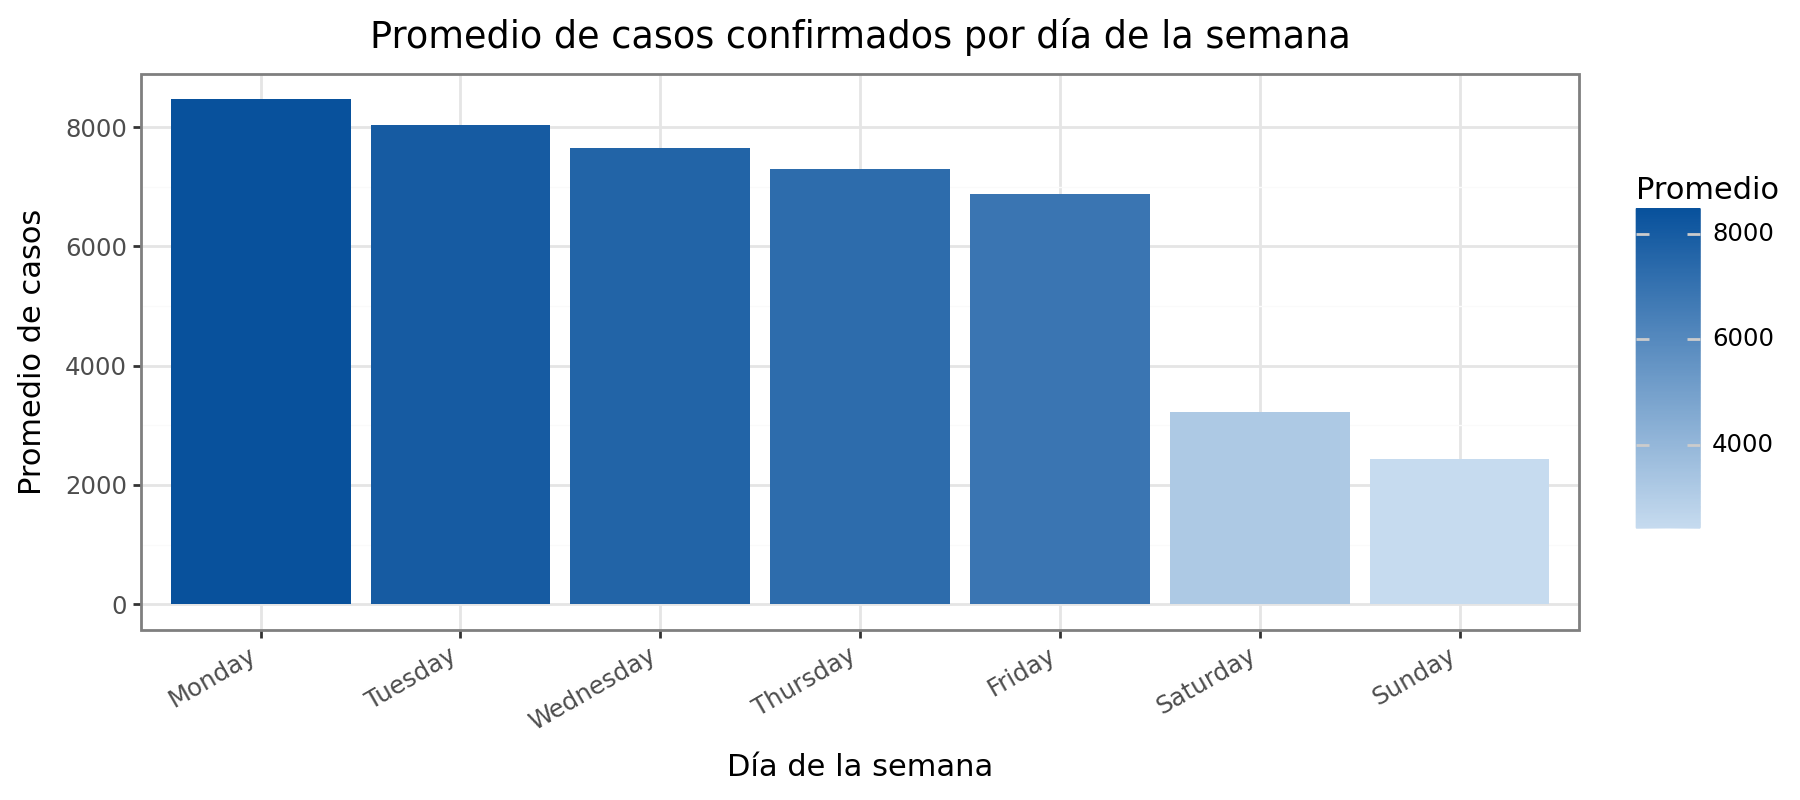

In [13]:
(ggplot(dist_dias, aes(x='dia', y='promedio', fill='promedio'))
 + geom_col()
 + scale_x_discrete(limits=DIAS_SEMANA)
 + scale_fill_gradient(low='#c6dbef', high='#08519c')
 + labs(title='Promedio de casos confirmados por día de la semana',
        x='Día de la semana', y='Promedio de casos', fill='Promedio')
 + theme_bw()
 + theme(figure_size=(9, 4),
         axis_text_x=element_text(rotation=30, hjust=1)))

### 3.3 Top 10 estados — barplot horizontal

`aes(x='reorder(entidad, total)')` ordena las barras por `total` de mayor a
menor, igual que `reorder()` en ggplot2. `coord_flip()` transpone los ejes:
las barras quedan horizontales sin tener que rotar nada manualmente.

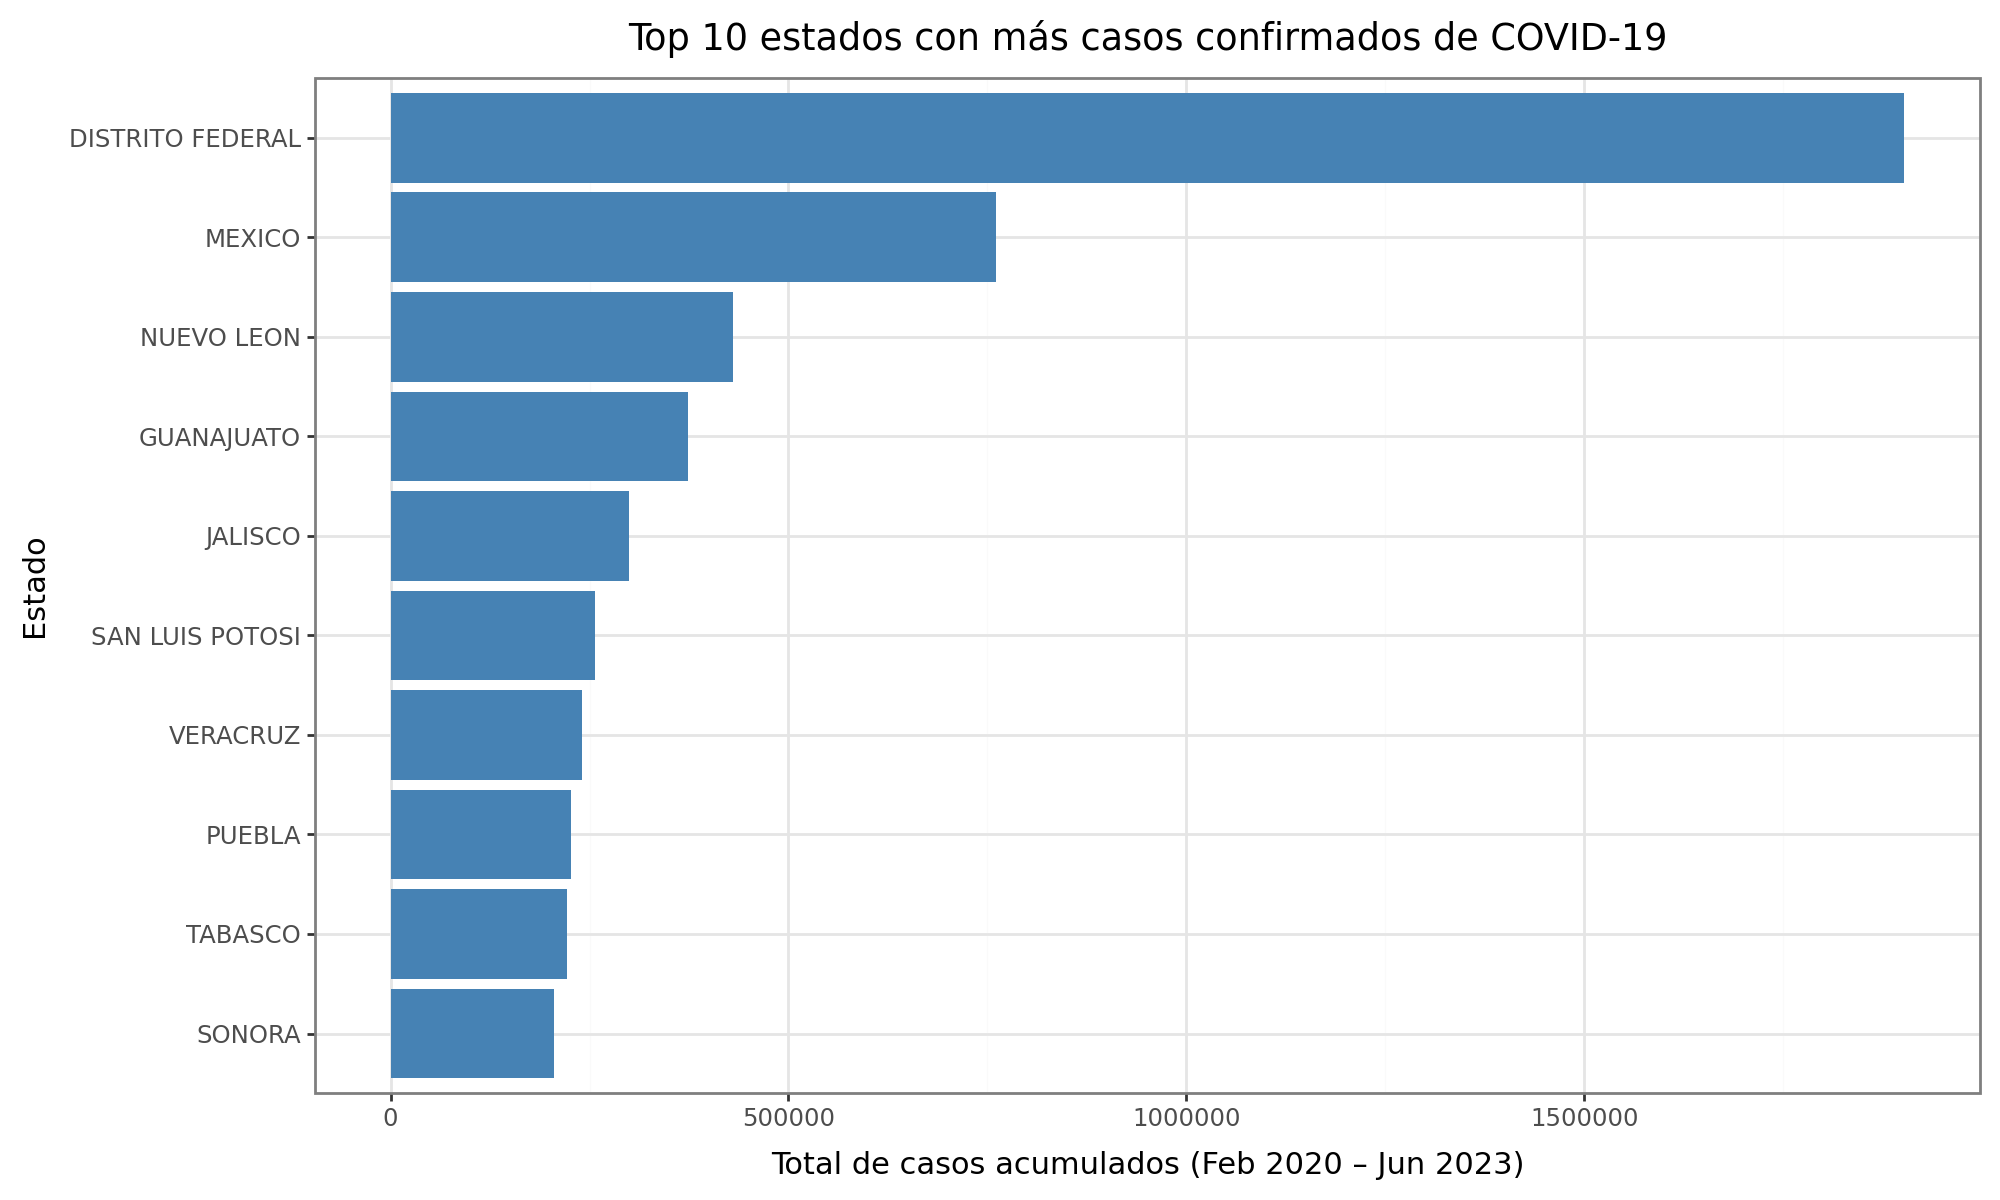

In [14]:
(ggplot(top_estados,
        aes(x='reorder(entidad, total)', y='total'))
 + geom_col(fill='steelblue')
 + coord_flip()
 + labs(title='Top 10 estados con más casos confirmados de COVID-19',
        x='Estado', y='Total de casos acumulados (Feb 2020 – Jun 2023)')
 + theme_bw()
 + theme(figure_size=(10, 6)))

### 3.4 Mapa de calor mensual — `geom_tile()`

`geom_tile()` dibuja un rectángulo por cada combinación (mes, estado)
coloreado según la variable `fill`. Es el equivalente en Plotnine de
`sns.heatmap()`, con la diferencia de que la escala de color se controla
declarativamente con `scale_fill_gradient()`.

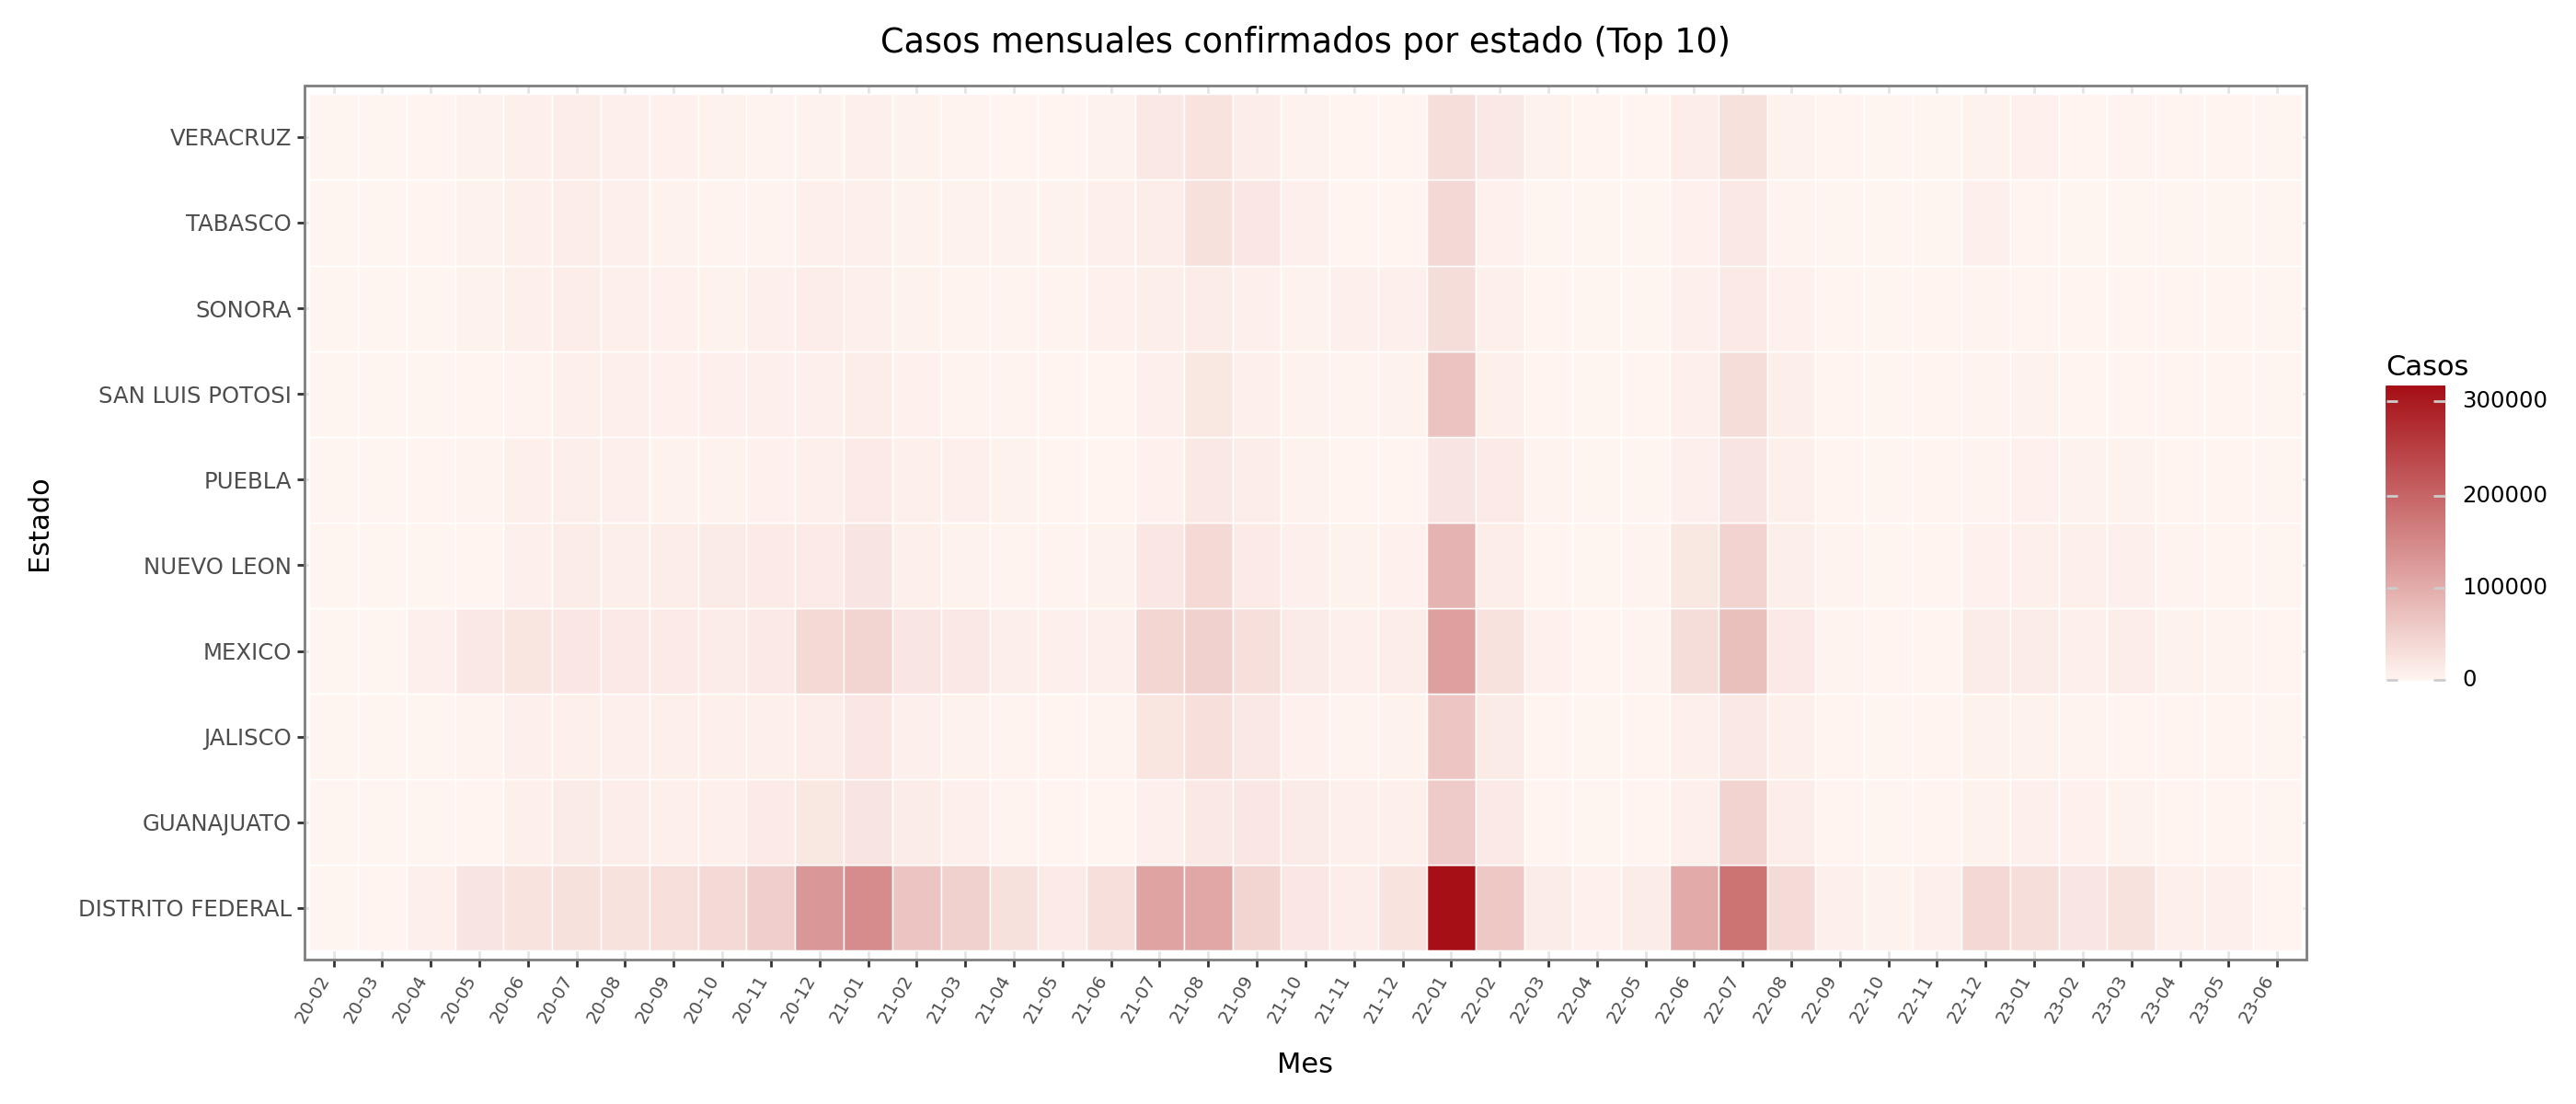

In [15]:
(ggplot(acumulados_mensuales,
        aes(x='mes_str', y='entidad', fill='casos'))
 + geom_tile(color='white', size=0.3)
 + scale_fill_gradient(low='#fff5f0', high='#a50f15')
 + labs(title='Casos mensuales confirmados por estado (Top 10)',
        x='Mes', y='Estado', fill='Casos')
 + theme_bw()
 + theme(figure_size=(14, 6),
         axis_text_x=element_text(rotation=60, hjust=1, size=7)))

### 3.5 Curvas epidémicas por estado — `facet_wrap()`

`facet_wrap('~ entidad', scales='free_y', ncol=2)` crea un panel
independiente por estado. `scales='free_y'` permite que cada panel tenga
su propia escala en Y, lo que revela la **forma** de la curva en estados
con pocos casos que quedarían aplastados bajo una escala compartida.

Comparar con el gráfico 3.3 del notebook anterior donde `sharey=False`
cumplía la misma función en `sns.FacetGrid`.

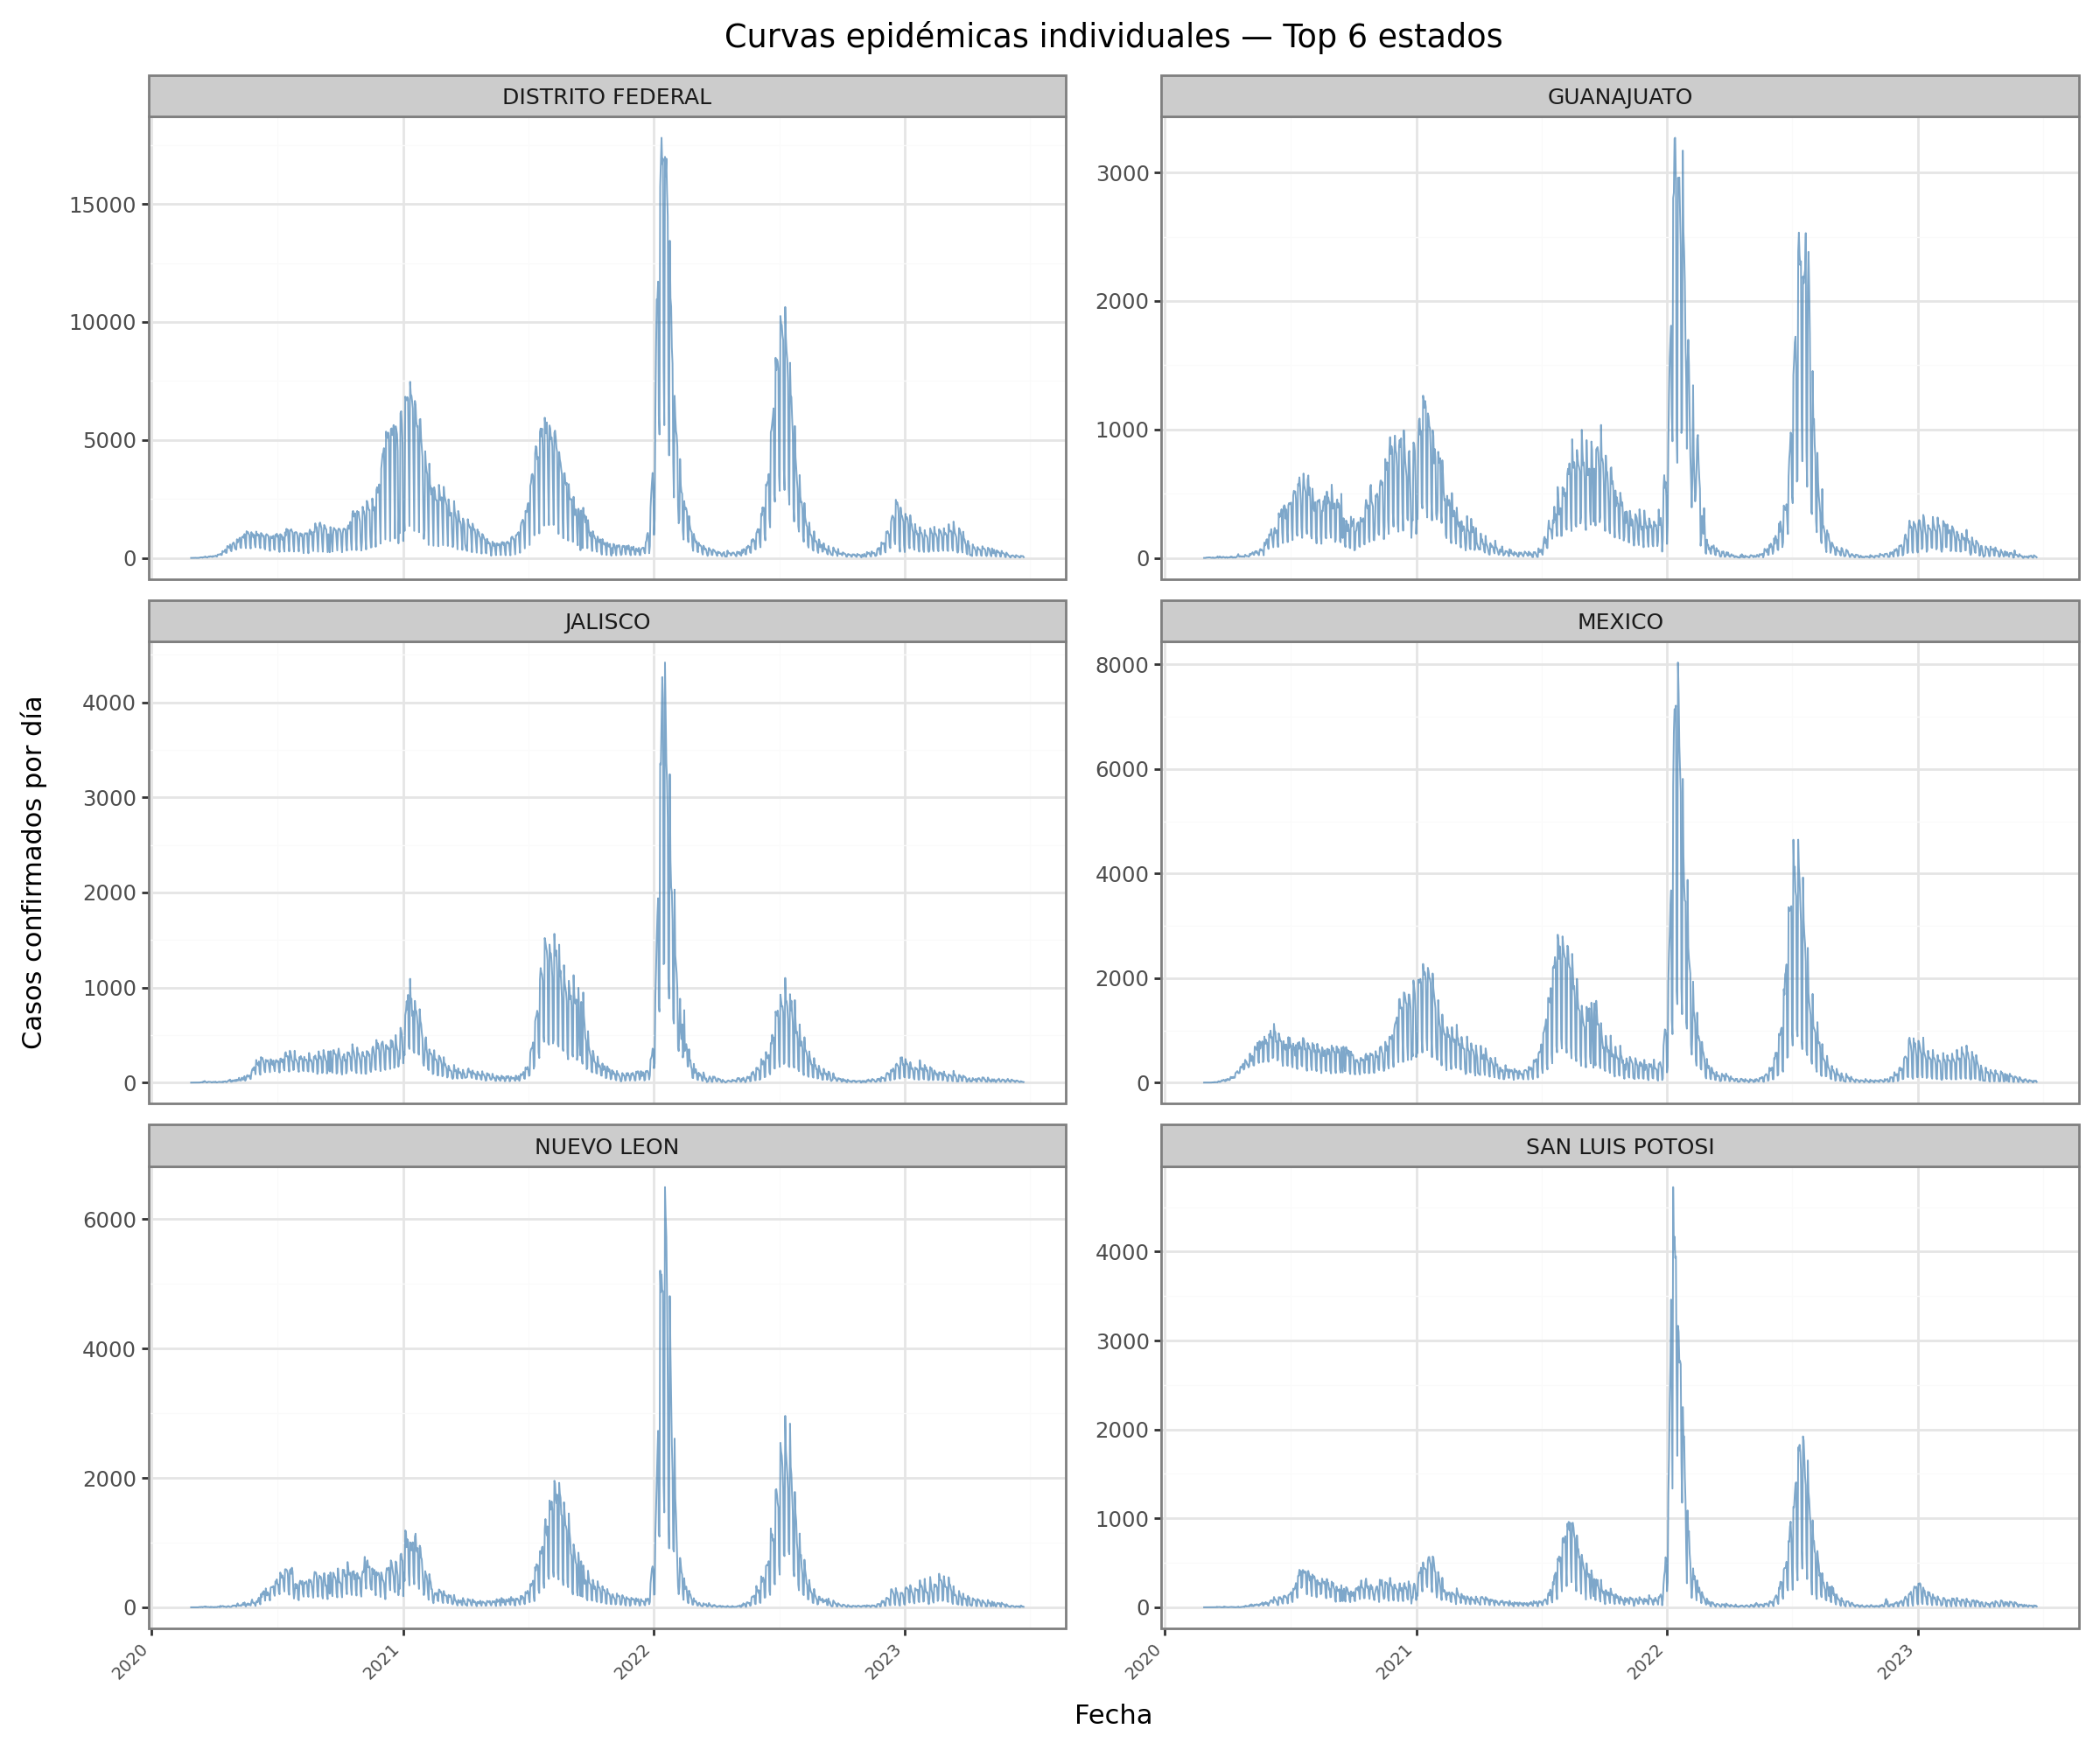

In [16]:
top_6_nombres = top_estados.head(6)['entidad'].to_list()
top_6_tidy = entidades_tidy.filter(
    pl.col('entidad').is_in(top_6_nombres)
)

(ggplot(top_6_tidy, aes(x='fecha', y='casos'))
 + geom_line(color='steelblue', size=0.4, alpha=0.7)
 + facet_wrap('entidad', scales='free_y', ncol=2)
 + scale_x_date(date_breaks='1 year', date_labels='%Y')
 + labs(title='Curvas epidémicas individuales — Top 6 estados',
        x='Fecha', y='Casos confirmados por día')
 + theme_bw()
 + theme(figure_size=(12, 10),
         strip_text=element_text(size=9),
         axis_text_x=element_text(rotation=45, hjust=1, size=7)))

### 3.6 Curva de incidencia acumulada *(nueva)*

`geom_area()` rellena el área bajo la curva de la línea, reforzando
visualmente la noción de volumen acumulado. Las inflexiones de la pendiente
corresponden exactamente a los picos de casos diarios: una pendiente empinada
indica una ola activa; una pendiente plana, un período de baja transmisión.

Esta perspectiva complementa a la curva diaria: mientras aquella muestra la
*velocidad* de la epidemia, esta muestra el *volumen* alcanzado.

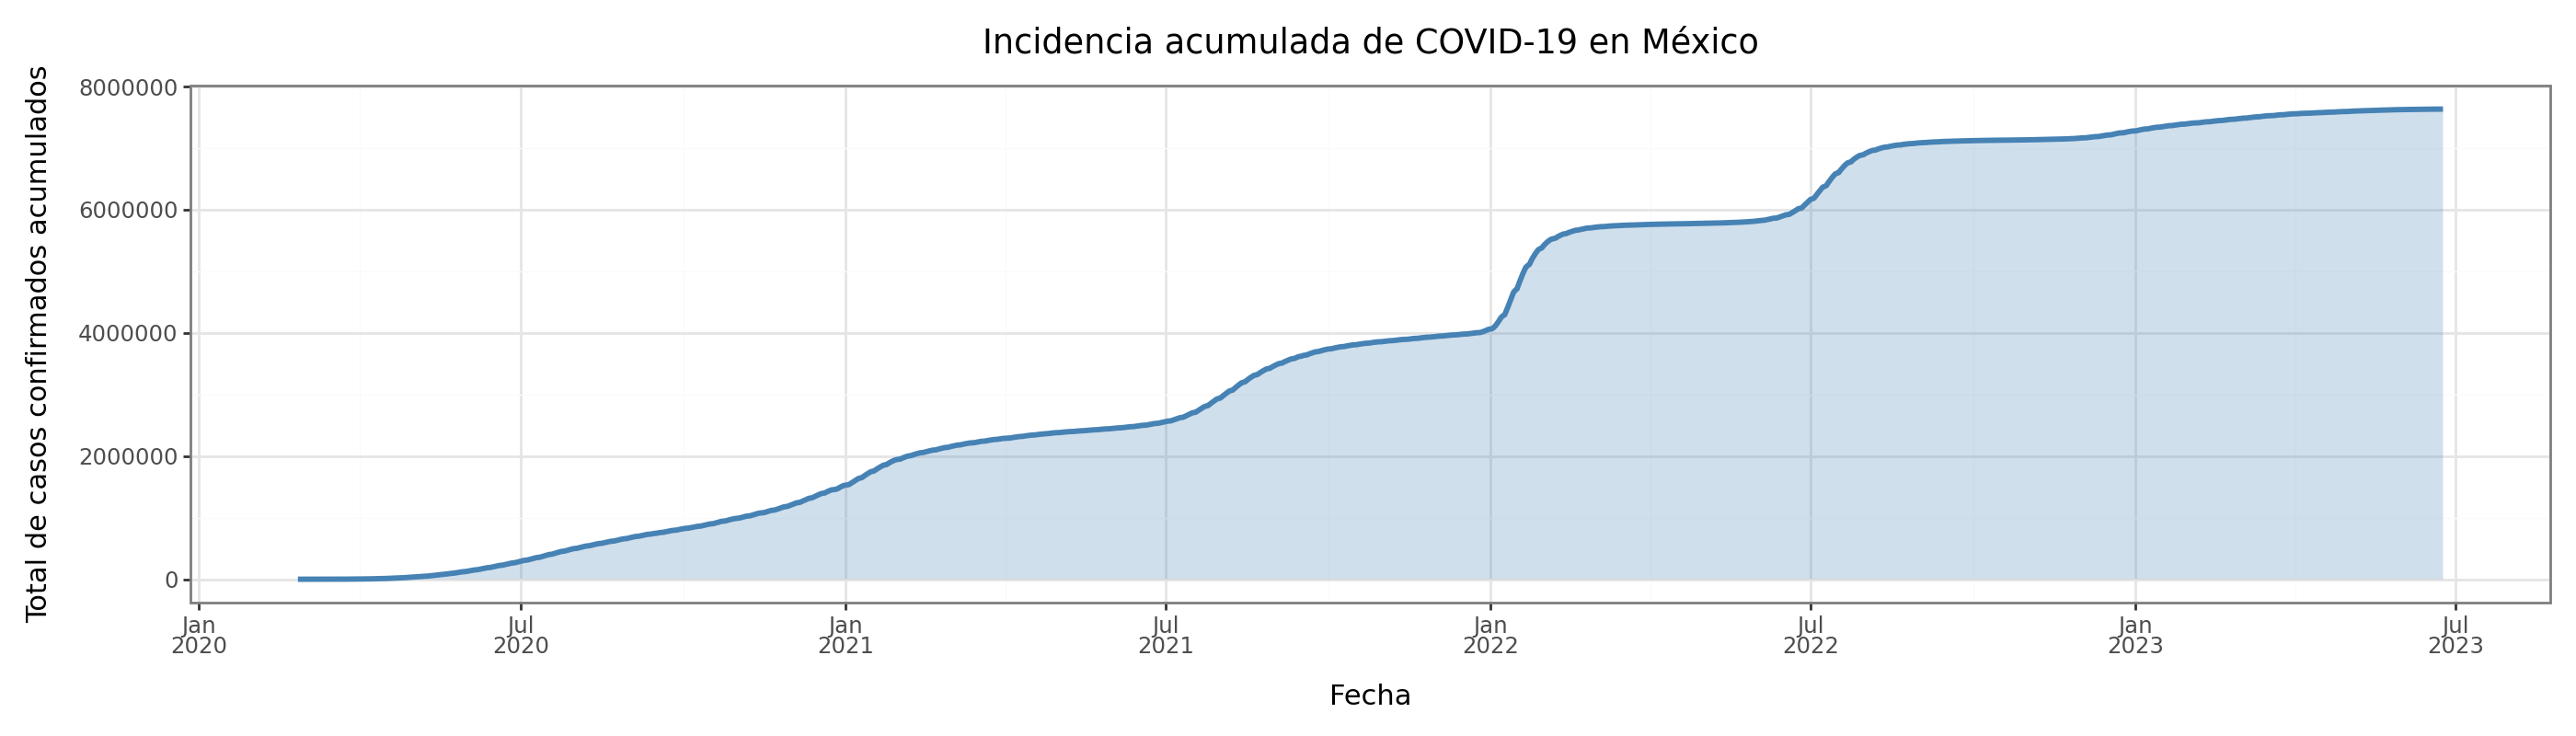

In [17]:
(ggplot(acumulado_nacional, aes(x='fecha', y='acumulado'))
 + geom_area(fill='steelblue', alpha=0.25)
 + geom_line(color='steelblue', size=1.2)
 + scale_x_date(date_breaks='6 months', date_labels='%b\n%Y')
 + labs(title='Incidencia acumulada de COVID-19 en México',
        x='Fecha',
        y='Total de casos confirmados acumulados')
 + theme_bw()
 + theme(figure_size=(14, 4)))

### 3.7 Distribución anual de casos confirmados *(nueva)*

`geom_boxplot()` muestra simultáneamente la mediana, el rango intercuartil
(IQR), los bigotes (±1.5 × IQR) y los valores atípicos.

Esta visualización responde preguntas que la curva diaria no responde
fácilmente: ¿qué tan *consistente* fue la carga de casos en cada año?
¿Hubo más variabilidad en 2021 (segunda ola) que en 2020?

`scale_fill_brewer(palette='Set2')` usa una paleta cualitativa de ColorBrewer,
apropiada para variables categóricas sin orden jerárquico.

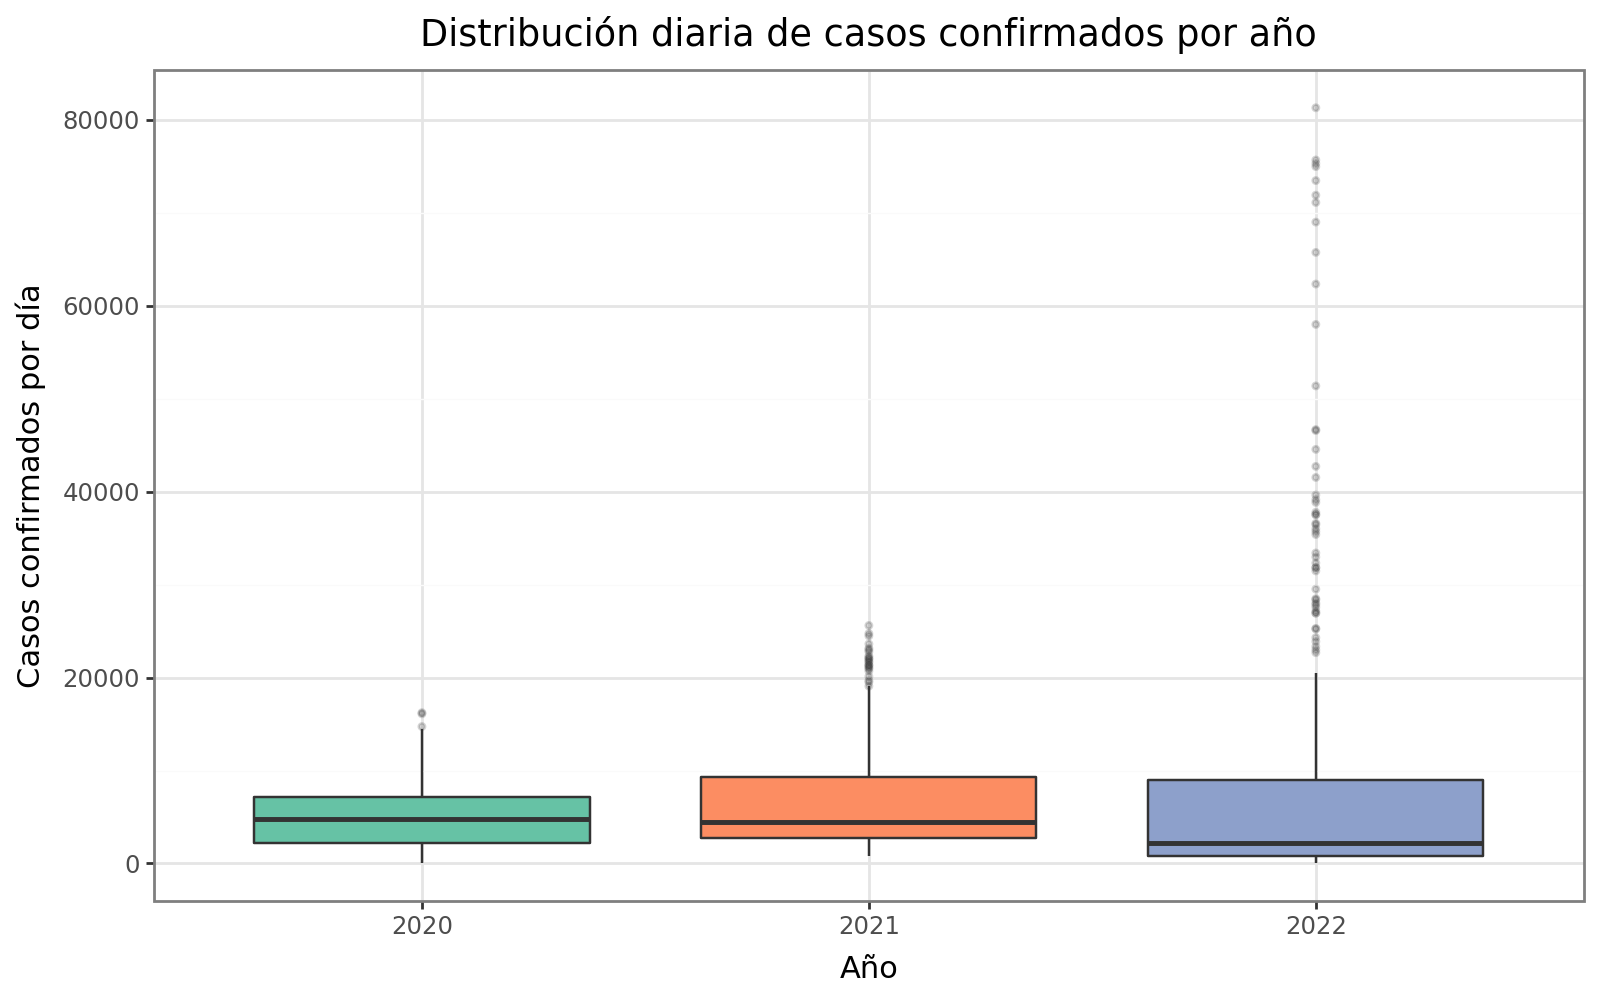

In [18]:
(ggplot(casos_por_anio, aes(x='año', y='casos', fill='año'))
 + geom_boxplot(outlier_alpha=0.2, outlier_size=0.8)
 + scale_fill_brewer(type='qual', palette='Set2')
 + labs(title='Distribución diaria de casos confirmados por año',
        x='Año', y='Casos confirmados por día', fill='Año')
 + theme_bw()
 + theme(figure_size=(8, 5), legend_position='none'))

---
## 📋 Conclusiones

### Polars vs. Pandas: diferencias clave observadas en este análisis

| Concepto | Pandas | Polars |
|----------|--------|--------|
| **Carga lazy** | No disponible (`read_csv` siempre eager) | `scan_csv()` + `.collect()` |
| **Formato tidy** | `melt()` al final del pipeline | `unpivot()` al inicio |
| **Media móvil** | `rolling(window='7d').mean()` | `rolling_mean(window_size=7)` |
| **Día de semana** | `dt.day_name()` | `dt.to_string('%A')` |
| **Resampleo temporal** | `resample('ME').sum()` | `group_by_dynamic(..., every='1mo')` |
| **Acumulado** | `cumsum()` | `cum_sum()` |

### Plotnine vs. Seaborn: diferencias clave

| Concepto | Seaborn | Plotnine |
|----------|---------|---------|
| **Filosofía** | Funciones de alto nivel | Gramática declarativa por capas |
| **Orden categórico** | `order=` en la función | `scale_x_discrete(limits=)` |
| **Paneles** | `FacetGrid` (objeto separado) | `facet_wrap()` integrado en el gráfico |
| **Escala de color** | `palette=` o `cmap=` | `scale_fill_*()` / `scale_color_*()` |
| **Eje horizontal** | `kind='barh'` | `coord_flip()` |

### Hallazgos analíticos

- La **distribución por día de la semana** confirma en ambos notebooks la
  hipótesis del ciclo artefactual de reporte: lunes y martes acumulan
  consistentemente más casos que fines de semana.
- La **curva acumulada** muestra tres inflexiones claras que delimitan las
  tres olas (verano 2020, invierno 2020-21, invierno 2021-22).
- El **boxplot anual** revela que 2021 tuvo la mayor *variabilidad* diaria
  (IQR más amplio), consecuencia de la segunda ola y la llegada de Ómicron
  a finales de año; 2022 tuvo el mayor volumen pero con distribución más
  homogénea gracias a la ola Ómicron sostenida.
- Las curvas por estado con `facet_wrap(scales='free_y')` muestran que la
  *forma* de la epidemia fue similar entre estados, pero su *magnitud*
  difiere en un orden de magnitud entre los estados más y menos afectados.

<p style="text-align: center">
  <a rel="license" href="http://creativecommons.org/licenses/by/4.0/">
    <img alt="Licencia Creative Commons" style="border-width:0"
         src="https://i.creativecommons.org/l/by/4.0/80x15.png" />
  </a><br />
  Esta obra está bajo una
  <a rel="license" href="http://creativecommons.org/licenses/by/4.0/">
    Licencia Creative Commons Atribución 4.0 Internacional
  </a>.
</p>

<p style="text-align: center">&copy; José Luis Chiquete Valdivieso. 2017-2026.</p>